In [64]:
import numpy as np
import matplotlib.pyplot as plt
import random
from scipy.special import softmax
import pandas as pd

In [3]:
reward = np.zeros((20, 20))

wall = -0.8
bump = -10
oil = -5
goal = 300
# surrounding
reward[:, 0] = wall
reward[0, :] = wall
reward[:, 19] = wall
reward[19, :] = wall

#first row
reward[1, 11:13] = bump
# 2nd row
reward[2, 1:4] = bump; reward[2, 8] = oil; reward[2, 16] = oil
# 3rd row
reward[3, 13] = goal
# 4th row
reward[4, 2] = oil; reward[4, 3:17] = wall
# 3rd and 5th columns
reward[4:8, 3] = wall; reward[2:5, 5] = wall
# 5th row
reward[5, 1] = bump; reward[5, 6] = oil; reward[5, 9] = bump
# 6th, 9th, 15th, and 17th columns
reward[6:13, 6] = wall; reward[6:11, 9] = wall; reward[6:12, 15]=wall; reward[5:9, 17]=bump
# 7th row
reward[7, 2] = bump; reward[7, 10:12] = bump; reward[7, 12:16]=wall
# 10th row
reward[10, 1:5] = wall; reward[10, 18] = oil
# 7th, 10th, 13th, 17th columns
reward[12:16, 7] = wall; reward[10:15, 10] = wall; reward[15:17, 10] = oil; reward[11:16, 13] = wall; reward[11:14, 17] = wall
# 11th row
reward[11, 15:18] = wall
# 12th row
reward[12, 3:8] = wall; reward[12, 11:13] = bump
# 14th row
reward[14, 1:3] = bump
# 15th row
reward[15, 17:19] = bump; reward[15, 13:17] = wall
# 16th row
reward[16, 7] = bump
# 17th row
reward[17, 1:3] = wall; reward[17, 7:13] = wall; reward[17, 14] = oil; reward[17, 17] = oil
# 18th row
reward[18, 7] = oil

reward


array([[ -0.8,  -0.8,  -0.8,  -0.8,  -0.8,  -0.8,  -0.8,  -0.8,  -0.8,
         -0.8,  -0.8,  -0.8,  -0.8,  -0.8,  -0.8,  -0.8,  -0.8,  -0.8,
         -0.8,  -0.8],
       [ -0.8,   0. ,   0. ,   0. ,   0. ,   0. ,   0. ,   0. ,   0. ,
          0. ,   0. , -10. , -10. ,   0. ,   0. ,   0. ,   0. ,   0. ,
          0. ,  -0.8],
       [ -0.8, -10. , -10. , -10. ,   0. ,  -0.8,   0. ,   0. ,  -5. ,
          0. ,   0. ,   0. ,   0. ,   0. ,   0. ,   0. ,  -5. ,   0. ,
          0. ,  -0.8],
       [ -0.8,   0. ,   0. ,   0. ,   0. ,  -0.8,   0. ,   0. ,   0. ,
          0. ,   0. ,   0. ,   0. , 300. ,   0. ,   0. ,   0. ,   0. ,
          0. ,  -0.8],
       [ -0.8,   0. ,  -5. ,  -0.8,  -0.8,  -0.8,  -0.8,  -0.8,  -0.8,
         -0.8,  -0.8,  -0.8,  -0.8,  -0.8,  -0.8,  -0.8,  -0.8,   0. ,
          0. ,  -0.8],
       [ -0.8, -10. ,   0. ,  -0.8,   0. ,   0. ,  -5. ,   0. ,   0. ,
        -10. ,   0. ,   0. ,   0. ,   0. ,   0. ,   0. ,   0. , -10. ,
          0. ,  -0.8],
       [ -

In [4]:
state_matrix = np.zeros((20, 20), dtype=int)
counter = 1

for i in range(20):
    for j in range(20):
        if reward[i, j] != wall:
            state_matrix[i, j] = counter
            counter += 1
state_matrix

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0],
       [  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
         13,  14,  15,  16,  17,  18,   0],
       [  0,  19,  20,  21,  22,   0,  23,  24,  25,  26,  27,  28,  29,
         30,  31,  32,  33,  34,  35,   0],
       [  0,  36,  37,  38,  39,   0,  40,  41,  42,  43,  44,  45,  46,
         47,  48,  49,  50,  51,  52,   0],
       [  0,  53,  54,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,  55,  56,   0],
       [  0,  57,  58,   0,  59,  60,  61,  62,  63,  64,  65,  66,  67,
         68,  69,  70,  71,  72,  73,   0],
       [  0,  74,  75,   0,  76,  77,   0,  78,  79,   0,  80,  81,  82,
         83,  84,   0,  85,  86,  87,   0],
       [  0,  88,  89,   0,  90,  91,   0,  92,  93,   0,  94,  95,   0,
          0,   0,   0,  96,  97,  98,   0],
       [  0,  99, 100, 101, 102, 103,   0, 104, 105,   0, 106, 1

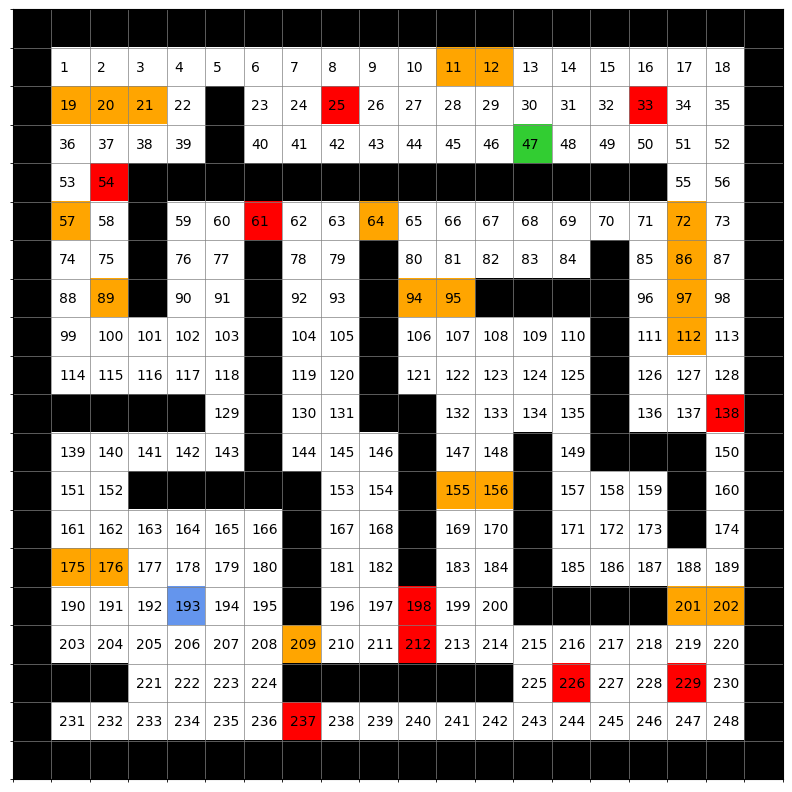

In [5]:
mapped_maze = np.zeros_like(reward)
mapped_maze[reward == -0.8] = 1  # Wall -> Black
mapped_maze[reward == -10] = 2   # Bump -> Orange
mapped_maze[reward == -5] = 3    # Oil -> Red
mapped_maze[reward == 300] = 4   # Goal -> Green
mapped_maze[15, 4] = 5 # Start -> Blue


cmap = plt.matplotlib.colors.ListedColormap(["white", "black", "orange", "red", "limegreen", "cornflowerblue"])

# Plot the reward with grid lines
fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(mapped_maze, cmap=cmap, origin="upper")

# Set grid lines
ax.set_xticks(np.arange(-0.5, 20, 1), minor=True)
ax.set_yticks(np.arange(-0.5, 20, 1), minor=True)
ax.grid(which="minor", color="gray", linestyle='-', linewidth=0.5)

for s in np.nditer(state_matrix[state_matrix!=0]):
    i = np.where(state_matrix==s)[0][0]
    j = np.where(state_matrix==s)[1][0]

    plt.text(j-0.3, i+0.1, str(int(s)), )

# Hide axis ticks
ax.set_xticks([])
ax.set_yticks([])

plt.show()

Next state and the reward

In [6]:
def next_state(s, a, p=0.025):
    row = np.where(state_matrix==s)[0][0]
    col = np.where(state_matrix==s)[1][0]
    s1 = [row, col]

    moves = {
        'U': [(-1, 0), (0, -1), (0, 1)],  # Up, Left, Right
        'D': [(1, 0), (0, -1), (0, 1)],   # Down, Left, Right
        'R': [(0, 1), (-1, 0), (1, 0)],   # Right, Up, Down
        'L': [(0, -1), (-1, 0), (1, 0)]   # Left, Up, Down
    }
    
    probabilities = [1 - p, p / 2, p / 2]  # Probabilities for main move and two deviations
    
    move = moves.get(a)
    
    chosen_move = move[np.random.choice([0, 1, 2], p=probabilities)]
    i = s1[0] + chosen_move[0]
    j = s1[1] + chosen_move[1]
    R = reward[i, j] - 1
    if reward[i, j] == wall:
        s2 = state_matrix[row, col]
    else:
        s2 = state_matrix[i, j]

    return R, s2


next_state(129, 'L')


(-1.8, 129)

# Temporal Difference Learning

In [7]:
# Parameters
gamma = 0.96
alpha = 0.25
beta = 0.05
epsilon = 0.1
episodes = 1000
max_step = 1000
actions = ["U", "D", "L", "R"]


epsilon-greedy function

In [8]:
def e_greedy(Q_value, epsilon = epsilon, actions = actions):
    if random.random() < epsilon:
        return random.choice(actions)
    else:
        return actions[np.argmax(Q_value)]

Required Functions

In [9]:
# Define a function to plot the optimal path from start to the goal

def plot_path(policy, s=[15, 4], title='Optimal Path'):
    cmap = plt.matplotlib.colors.ListedColormap(["white", "black", "orange", "red", "limegreen", "cornflowerblue"])

    # Plot the reward with grid lines
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.imshow(mapped_maze, cmap=cmap, origin="upper")

    # Set grid lines
    ax.set_xticks(np.arange(-0.5, 20, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, 20, 1), minor=True)
    ax.grid(which="minor", color="gray", linestyle='-', linewidth=0.5)

    # Hide axis ticks
    ax.set_xticks([])
    ax.set_yticks([])
    
    i = s[0]; j=s[1]
    s = state_matrix[i, j]
    memory = [s]

    while s!= 47:
        
        if policy[s-1] == "U":
            plt.arrow(j, i+0.35, 0, -0.5, width=0.04, color='black')  # Up
            i -= 1
        elif policy[s-1] == "R":
            plt.arrow(j-0.35, i, 0.5, 0, width=0.04, color='black')  # Right
            j += 1
        elif policy[s-1] == "D":
            plt.arrow(j, i-0.35, 0, 0.50, width=0.04, color='black')  # Down
            i += 1
        else:
            plt.arrow(j+0.35, i, -0.5, 0, width=0.04, color='black')  # Left
            j -= 1
        s = state_matrix[i, j]
        if s in memory:
            break
        else:
            memory.append(s)
    plt.title(title)
    plt.show()
    return


In [10]:
def plot_policy(policy, title='Optimal Policy'):
    cmap = plt.matplotlib.colors.ListedColormap(["white", "black", "orange", "red", "limegreen", "cornflowerblue"])

    # Plot the reward with grid lines
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.imshow(mapped_maze, cmap=cmap, origin="upper")

    # Set grid lines
    ax.set_xticks(np.arange(-0.5, 20, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, 20, 1), minor=True)
    ax.grid(which="minor", color="gray", linestyle='-', linewidth=0.5)

    # Hide axis ticks
    ax.set_xticks([])
    ax.set_yticks([])

        
    for s in np.nditer(state_matrix[(state_matrix!=0) & (state_matrix!=47)]):
        i = np.where(state_matrix==s)[0][0]
        j = np.where(state_matrix==s)[1][0]
        if policy[s-1] == "U":
            plt.arrow(j, i+0.35, 0, -0.5, width=0.04, color='black')  # Up
        elif policy[s-1] == "R":
            plt.arrow(j-0.35, i, 0.5, 0, width=0.04, color='black')  # Right
        elif policy[s-1] == "D":
            plt.arrow(j, i-0.35, 0, 0.50, width=0.04, color='black')  # Down
        else:
            plt.arrow(j+0.35, i, -0.5, 0, width=0.04, color='black')  # Left
    plt.title(title)
    plt.show()
    
    return


Run an algorithm 10 timee, average the accumulated reward, and plot the optimal policy/path

In [11]:
def Avg_AccReward(algorithm, r=10):
    example = random.randint(0, r-1)
    AvgAcReward = np.zeros(episodes)  # Store average accumulated reward per episode

    for run in range(r):
        policy, rew = algorithm()
        AvgAcReward += np.array(rew)  # Accumulate rewards

        if run == example:
            plot_path(policy, title=f'Optimal Path: {algorithm.__name__}')
            plot_policy(policy, title=f'Optimal Policy: {algorithm.__name__}')
    output = AvgAcReward / r 
    plt.plot(output)
    plt.title(f'Average Accumulated Rewards: {algorithm.__name__}')
    # plt.ylim(-2, 5)
    plt.show()
    
    return output

# 1. Q-Learning

In [21]:
initialQ = np.zeros((248, 4))  # for all states and actions in order of Up, Down, Right, and Left
state_array = reward.flatten()[reward.flatten() != wall]

def QLearning(initialQ=initialQ, episodes=episodes, actions=actions, alpha=alpha, gamma=gamma):
    reach_goal = 0
    optimal_policies = []
    Q_values = initialQ.copy()
    AccRew = 0
    AcReward = np.zeros(episodes)  # Store accumulated reward per episode
    
    for episode in range(episodes):
        s0 = 193
        step = 0
        rew = 0
        
        while step < max_step:
            action = e_greedy(Q_values[s0-1])
            R, s_prime = next_state(s0, action)
            rew += R

            if state_array[s_prime - 1] == goal:
                # Terminal update: no future reward
                Q_values[s0-1, actions.index(action)] += alpha * (R - Q_values[s0-1, actions.index(action)])
                reach_goal += 1
                break
            else:
                # Non-terminal update: use the max over next state's Q-values
                Q_values[s0-1, actions.index(action)] += alpha * (R + gamma * np.max(Q_values[s_prime-1]) - Q_values[s0-1, actions.index(action)])
                s0 = s_prime

            step += 1
        AccRew += rew/step
        
        AcReward[episode] = AccRew/(episode+1)
    optimal_policies = [actions[i] for i in np.argmax(Q_values, axis=1)]
    print(f"Reached Goal: {reach_goal} times")
    return optimal_policies, AcReward

Reached Goal: 977 times
Reached Goal: 979 times
Reached Goal: 976 times
Reached Goal: 979 times


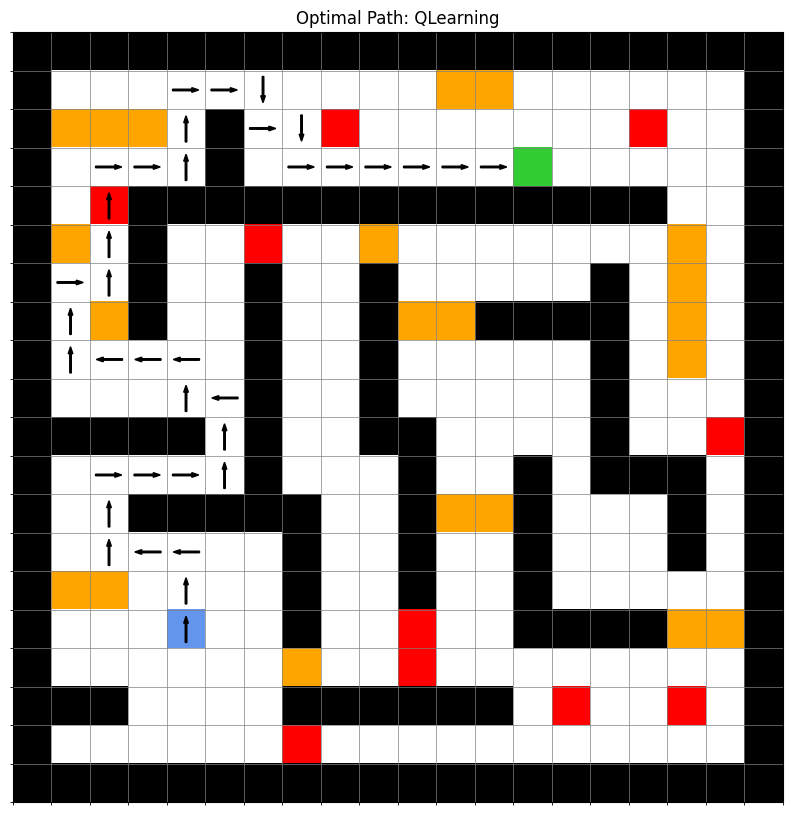

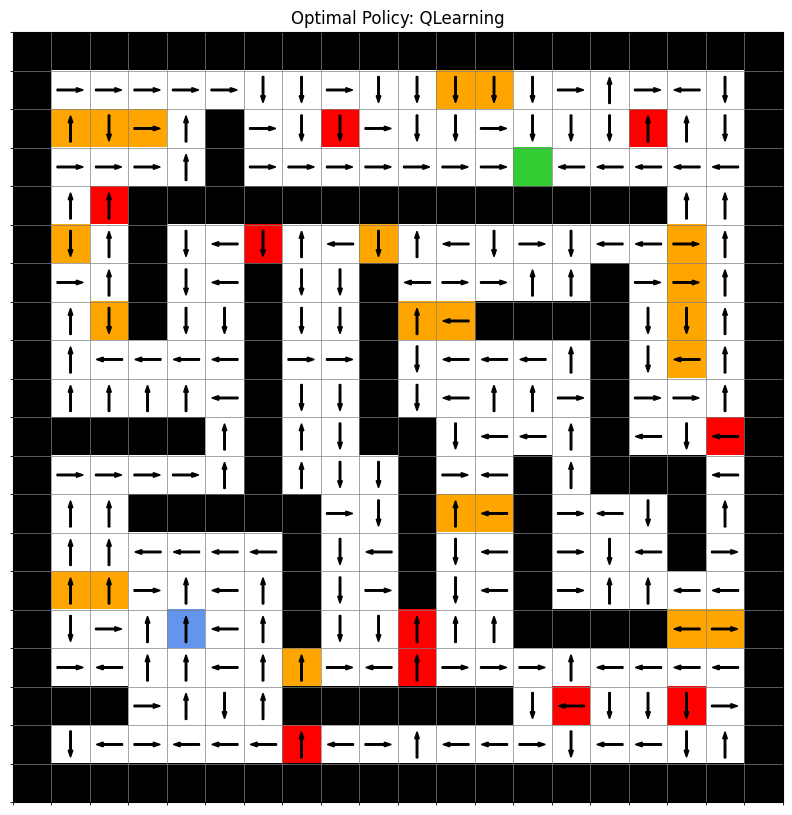

Reached Goal: 979 times
Reached Goal: 980 times
Reached Goal: 969 times
Reached Goal: 978 times
Reached Goal: 979 times
Reached Goal: 979 times


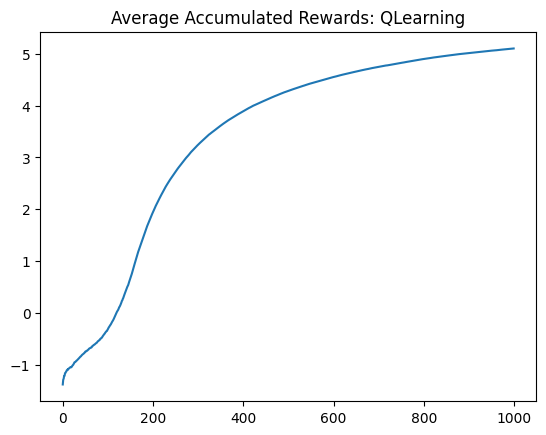

In [22]:
QLearn_reward = Avg_AccReward(QLearning)

# 2. SARSA

In [24]:

initialQ = np.zeros((248, 4)) # for all states and actions in order of Up, Dowm, Right, and Left
state_array = reward.flatten()[reward.flatten()!=wall]
def SARSA(initialQ=initialQ, episodes = episodes, actions = actions, alpha=alpha, gamma = gamma):
    reach_goal = 0
    optimal_policies = []
    Q_values = initialQ.copy()
    AccRew = 0
    AcReward = []
    for episode in range(episodes):
        s0 = 193
        step = 0
        rew = 0
        action = e_greedy(Q_values[s0-1])
        while step <max_step:
            # Observe
            R, s_prime = next_state(s0, action)
            rew += R
            # choose action in next step
            a_prime = e_greedy(Q_values[s_prime-1])
            step+=1
            if state_array[s_prime - 1] == goal:
                Q_values[s0-1, actions.index(action)] += alpha*(R - Q_values[s0-1, actions.index(action)])
                reach_goal += 1
                break
            else:
                Q_values[s0-1, actions.index(action)] += alpha*(R + gamma*Q_values[s_prime-1, actions.index(a_prime)] - Q_values[s0-1, actions.index(action)])
                s0=s_prime
                action = a_prime
        AccRew += rew/step
    
        AcReward.append(AccRew/(episode+1))
    optimal_policies = [actions[i] for i in np.argmax(Q_values, axis = 1)]
    print(reach_goal)
    return optimal_policies, AcReward

965
980
976
976
977
973
977


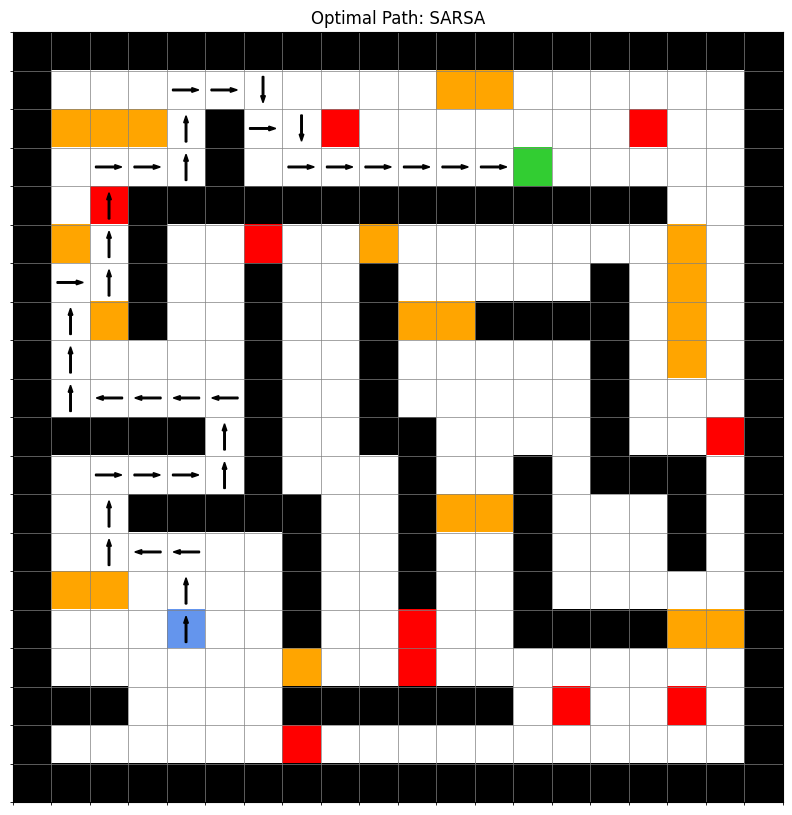

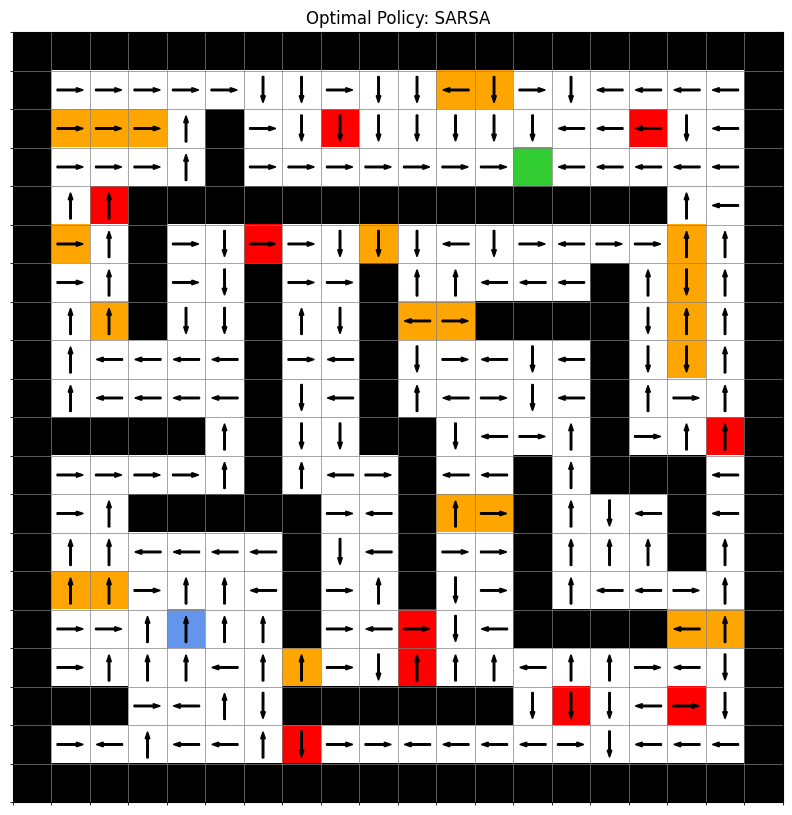

978
974
980


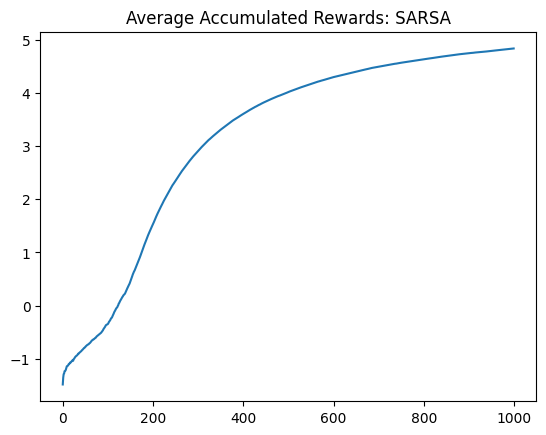

In [25]:
SARSA_reward = Avg_AccReward(SARSA)

# 3. Tabular Actor Critic

The gamma value is adjusted so that the algorithm leads to convergence. With the defined gamma value 0.96, the algorithm could not converge.

In [26]:
initialQ = np.zeros((248, 4))  # for all states and actions in order of Up, Down, Right, and Left
state_array = reward.flatten()[reward.flatten() != wall]

def ActorCritic(actions=actions, episodes=episodes, gamma=0.99, alpha=alpha, beta=beta, max_step=max_step):
    
    values = np.zeros(248)
    H_values = np.zeros((248, len(actions)))
    AcRew =0
    AcReward = []
    reach_goal = 0
    
    for episode in range(episodes):
        s0 = 193
        step = 0
        rew = 0
        while step < max_step:
            
            probs = softmax(H_values[s0 - 1])
            
            action = np.random.choice(actions, p=probs)
            
            R, s_prime = next_state(s0, action)
            rew += R
            delta = R + gamma * values[s_prime - 1] - values[s0 - 1]
            values[s0 - 1] += alpha * delta
            
            i = actions.index(action)
            H_values[s0 - 1, i] += beta * delta * (1 - probs[i])
            
            step += 1
            if state_array[s_prime - 1] == goal:
                reach_goal += 1
                break
            s0 = s_prime
        
        AcRew += rew/step
        AcReward.append(AcRew/(episode+1))
    
    print("Reached goal count:", reach_goal)
    
    # After training, derive the optimal policy by taking the action with highest preference per state
    optimal_policy = [actions[i] for i in np.argmax(H_values, axis=1)]
    return optimal_policy, AcReward

Reached goal count: 986
Reached goal count: 980
Reached goal count: 978
Reached goal count: 985
Reached goal count: 980
Reached goal count: 978


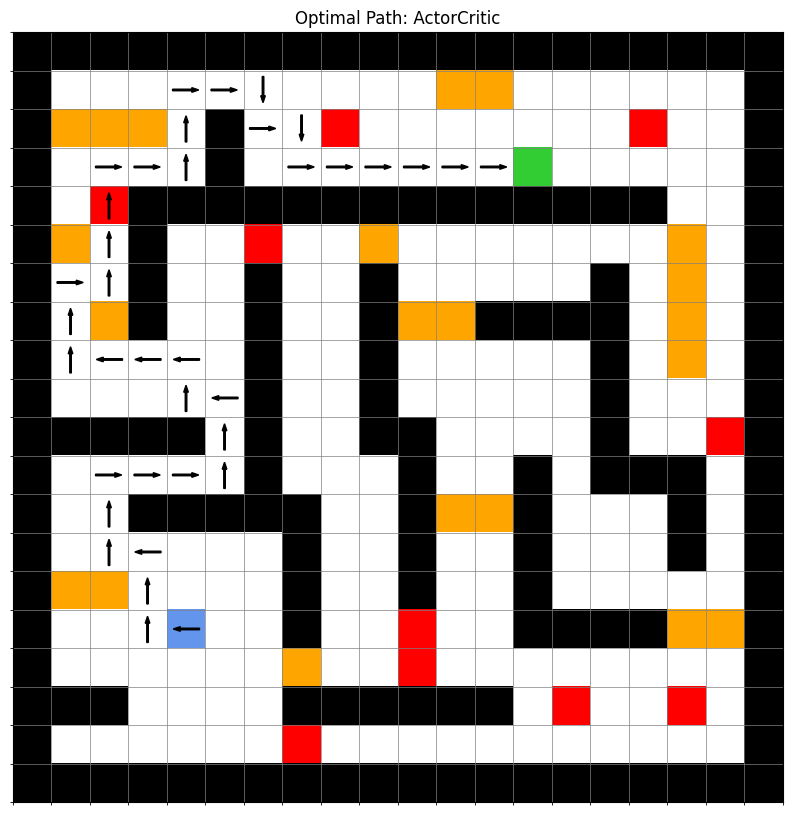

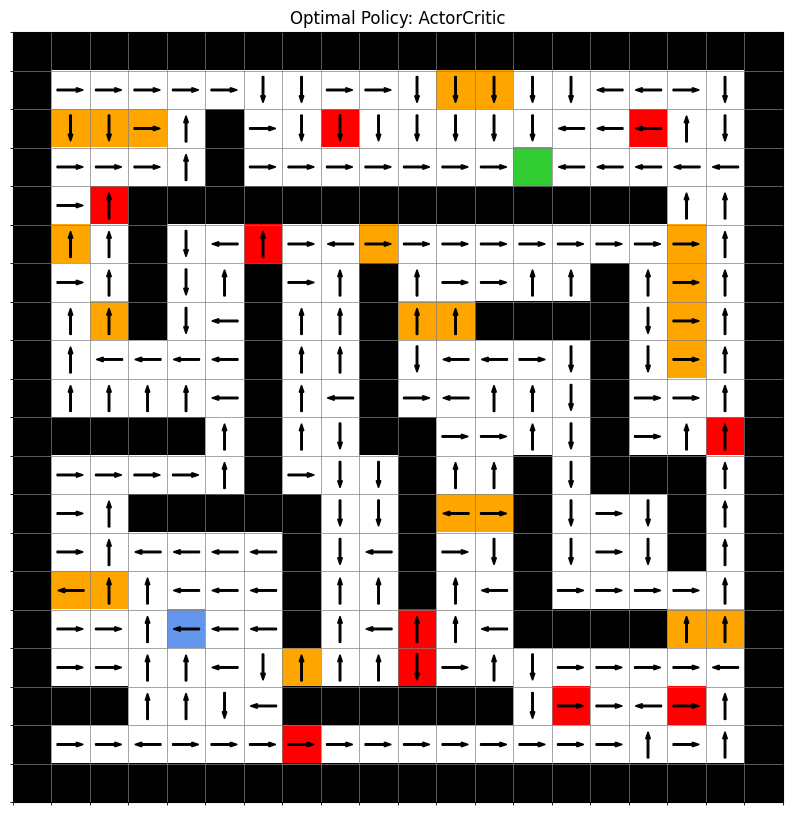

Reached goal count: 975
Reached goal count: 971
Reached goal count: 974
Reached goal count: 976


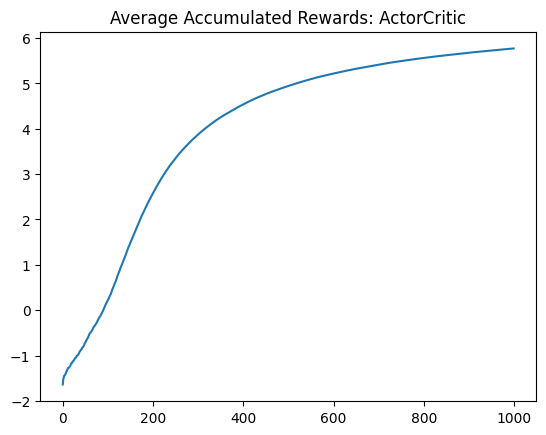

In [27]:
ActCrit_reward = Avg_AccReward(ActorCritic)

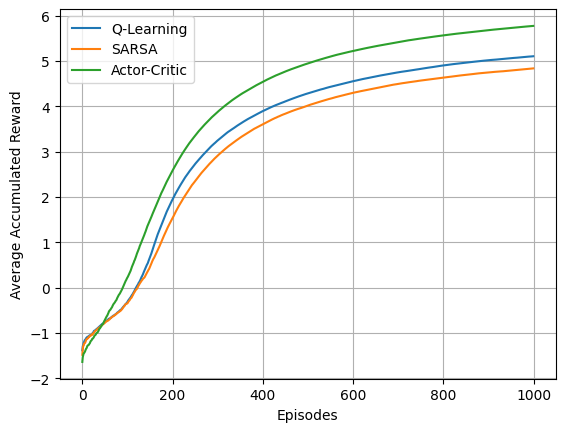

In [ ]:
plt.plot(QLearn_reward, label='Q-Learning')
plt.plot(SARSA_reward, label='SARSA')
plt.plot(ActCrit_reward, label='Actor-Critic')

plt.xlabel('Episodes')
plt.ylabel('Average Accumulated Reward')
plt.legend()
plt.grid()
plt.show()

# Problem 2

In [29]:
import numpy as np
import random

In [80]:
# Define Parameters

gamma = 0.9
alpha = 0.25
beta = 0.05
epsilon = 0.15
p = 0.1
episodes = 1000
steps = 100
lam = 0.95

C = np.array([[0, 0, -1, 0], [1, 0, -1, -1], [0, 1, 0, 0], [-1, 1, 1, 0]])
actions = [np.array([0,0,0,0]), np.array([0,1,0,0]), np.array([0,0,1,0]), np.array([0,0,0,1])]
cost = [0, 1, 1, 0]
states = [np.array(list(map(int, format(k, '04b')))) for k in range(16)]

def transition(s0, action, p=p, C=C):
    
    noise = random.choices([0, 1], weights=[1-p, p], k=4)
    s_prime = np.bitwise_xor(np.bitwise_xor((np.dot(C, states[s0-1])>0), actions[action-1]), noise)
    R = np.dot(np.array([5, 5, 5, 5]), s_prime.T) - cost[action-1]
    s_prime = np.where(np.all(s_prime == states, axis=1))[0][0]
    return R, s_prime+1


def Avg_AccReward(algorithm, r = 10):
    AvgAcReward = np.zeros(episodes)
    policies = []
    for r in range(r):
        policy, rew = algorithm()
        AvgAcReward += np.array(rew)
        policies.append(policy)
    plt.plot(AvgAcReward/r)
    plt.title(f'Average Accumulated Reward - {algorithm.__name__}')
    plt.show()

    return policies, AvgAcReward/r

In [81]:
states[transition(8, 4)[0]-1]

array([0, 1, 0, 0])

# Q-Learning

In [82]:
initialQ = np.zeros((16, 4)) # for all states and actions

def QLearning(initialQ=initialQ, states = states, actions = actions, episodes = episodes, steps = steps, alpha=alpha, gamma = gamma):
    reach_goal = 0
    optimal_policies = []
    Q_values = initialQ.copy()
    AcRew = 0
    AcReward = []
    for episode in range(episodes):
        s0 = random.randint(1, 16)
        step = 0
        rew = 0
        while step <steps:
            action = e_greedy(Q_values[s0-1], epsilon=epsilon, actions=actions)
            # Observe
            a = np.where(np.all(action == actions, axis=1))[0][0]
            R, s_prime = transition(s0, a)
            rew += R
            
            Q_values[s0-1, a] += alpha * (R + gamma * np.max(Q_values[s_prime-1]) - Q_values[s0-1, a])
            step+=1
            s0=s_prime
        AcRew += rew/step
        optimal_policies.append([f'a{i+1}' for i in np.argmax(Q_values, axis = 1)])
        AcReward.append(AcRew/(episode+1))
    # print(reach_goal)
    return optimal_policies[-1], AcReward


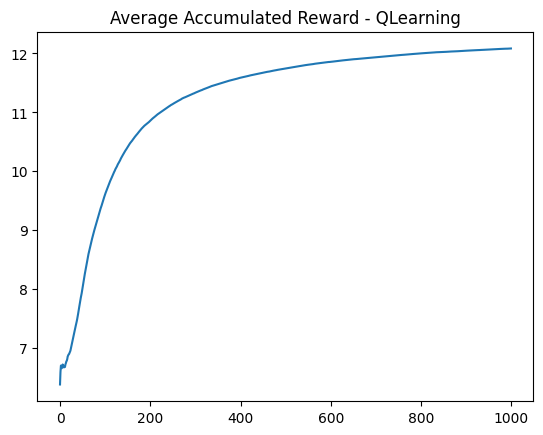

In [83]:
QLearn_policies, QLearn_reward2 = Avg_AccReward(QLearning)

In [84]:
pd.DataFrame(QLearn_policies)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,a3,a3,a4,a3,a3,a3,a3,a3,a1,a4,a3,a3,a1,a3,a3,a3
1,a3,a3,a3,a3,a3,a3,a3,a3,a4,a1,a3,a3,a1,a3,a3,a2
2,a3,a3,a3,a3,a3,a3,a3,a3,a1,a3,a3,a4,a1,a3,a3,a3
3,a3,a3,a3,a3,a3,a3,a3,a3,a1,a3,a3,a3,a2,a3,a3,a3
4,a3,a3,a3,a3,a3,a3,a3,a3,a1,a1,a3,a3,a1,a1,a3,a3
5,a3,a3,a3,a3,a3,a3,a3,a3,a1,a3,a3,a3,a1,a3,a3,a3
6,a3,a3,a3,a3,a3,a3,a3,a3,a4,a3,a4,a3,a1,a3,a3,a3
7,a3,a3,a3,a3,a3,a3,a3,a3,a1,a3,a3,a3,a1,a3,a3,a3
8,a3,a3,a3,a3,a3,a3,a3,a3,a2,a3,a3,a3,a1,a3,a3,a3
9,a3,a3,a3,a3,a3,a3,a3,a3,a4,a3,a3,a3,a1,a2,a3,a3


# SARSA

In [85]:
initialQ = np.zeros((16, 4)) # for all states and actions

def SARSA(initialQ=initialQ, states = states, actions = actions, episodes = episodes, steps = steps, alpha=alpha, gamma = gamma):
    reach_goal = 0
    optimal_policies = []
    Q_values = initialQ.copy()
    AcRew = 0
    AcReward = []
    for episode in range(episodes):
        s0 = random.randint(1, 16)
        step = 0
        rew = 0
        action = e_greedy(Q_values[s0-1], epsilon=epsilon, actions=actions)
        while step <steps:

            # Observe
            a = np.where(np.all(action == actions, axis=1))[0][0]
            R, s_prime = transition(s0, a)
            rew += R
            next_action = e_greedy(Q_values[s0-1], epsilon=epsilon, actions=actions)
            a_prime = np.where(np.all(next_action == actions, axis=1))[0][0]
            Q_values[s0-1, a] += alpha * (R + gamma * Q_values[s_prime-1, a_prime] - Q_values[s0-1, a])
            step+=1
            s0=s_prime
            action=next_action
        AcRew += rew/step
        optimal_policies.append([f'a{i+1}' for i in np.argmax(Q_values, axis = 1)])
        AcReward.append(AcRew/(episode+1))
    # print(reach_goal)
    return optimal_policies[-1], AcReward


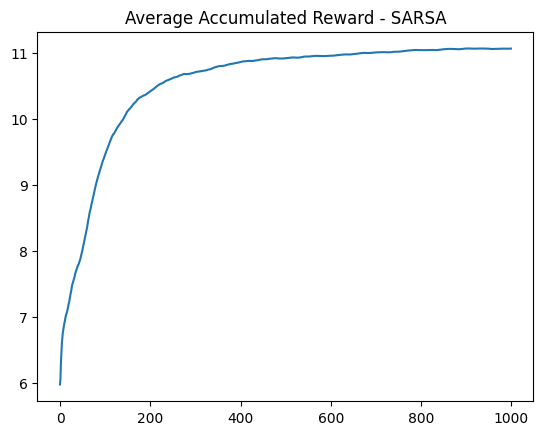

In [86]:
SARSA_policies, SARSA_reward2 = Avg_AccReward(SARSA)

In [87]:
pd.DataFrame(SARSA_policies)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,a3,a4,a3,a4,a3,a3,a3,a3,a1,a3,a3,a3,a1,a3,a3,a3
1,a3,a3,a3,a4,a3,a3,a3,a3,a4,a4,a4,a4,a1,a1,a3,a3
2,a3,a3,a3,a3,a3,a3,a3,a3,a4,a3,a3,a3,a1,a3,a3,a3
3,a1,a3,a4,a4,a3,a3,a3,a3,a1,a3,a3,a3,a1,a3,a3,a3
4,a3,a1,a3,a3,a3,a3,a3,a3,a1,a4,a3,a4,a1,a3,a3,a3
5,a3,a3,a3,a4,a3,a3,a3,a3,a1,a3,a4,a3,a1,a3,a3,a3
6,a3,a3,a4,a3,a3,a3,a3,a3,a4,a3,a3,a3,a1,a3,a3,a3
7,a3,a3,a3,a3,a3,a3,a3,a3,a2,a3,a3,a3,a1,a3,a3,a3
8,a4,a3,a3,a3,a3,a3,a3,a3,a1,a3,a1,a4,a1,a3,a3,a3
9,a3,a3,a3,a4,a3,a3,a3,a3,a4,a3,a4,a1,a1,a3,a3,a3


In [97]:
def SARSA_lambda(states = states, actions = actions, episodes = episodes, steps = steps, alpha=alpha, gamma = gamma, lam = lam):
    Q_values = np.zeros((16, 4))
    optimal_policies = []
    AcRew = 0
    AcReward = []
    reach_goal = 0
    for episode in range(episodes):
        e_sa = np.zeros((16, 4))
        s0 = random.randint(1, 16)
        step = 0
        rew = 0
        action = e_greedy(Q_values[s0-1], epsilon=epsilon, actions=actions)
        while step <steps:
            
            # Observe
            a = np.where(np.all(action == actions, axis=1))[0][0]
            R, s_prime = transition(s0, a)
            rew += R
            next_action = e_greedy(Q_values[s0-1], epsilon=epsilon, actions=actions)
            a_prime = np.where(np.all(next_action == actions, axis=1))[0][0]
            delta = R + gamma * Q_values[s_prime-1, a_prime] - Q_values[s0-1, a]
            e_sa[s0-1, a] += 1
            Q_values[s0-1, a] += alpha * delta * e_sa[s0-1, a]
            e_sa = e_sa*gamma*lam
            step+=1
            s0=s_prime
            action = next_action
        AcRew += rew/step
        optimal_policies.append([f'a{i+1}' for i in np.argmax(Q_values, axis = 1)])
        AcReward.append(AcRew/(episode+1))
    # print(reach_goal)
    return optimal_policies[-1], AcReward


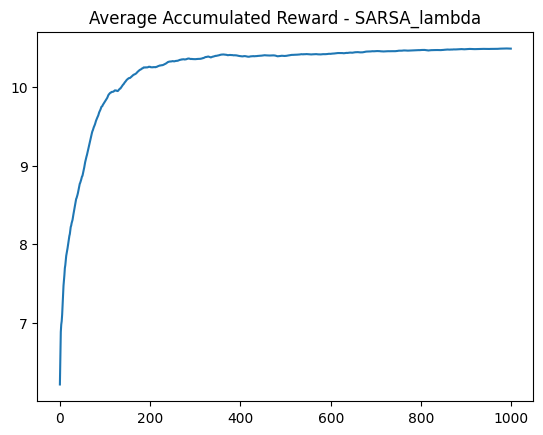

In [98]:
SARSA_lambda_policies, SARSA_lambda_reward = Avg_AccReward(SARSA_lambda)

In [99]:
pd.DataFrame(SARSA_lambda_policies)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,a3,a1,a3,a3,a3,a3,a3,a2,a1,a4,a1,a3,a1,a3,a3,a3
1,a3,a3,a3,a3,a3,a3,a3,a3,a4,a4,a3,a3,a1,a1,a3,a3
2,a3,a3,a4,a3,a3,a3,a3,a3,a4,a3,a4,a3,a1,a3,a3,a3
3,a3,a3,a4,a3,a3,a3,a3,a3,a1,a4,a4,a3,a1,a3,a3,a3
4,a3,a3,a3,a3,a3,a3,a3,a3,a1,a3,a1,a4,a2,a1,a3,a3
5,a3,a3,a3,a3,a3,a3,a3,a2,a4,a1,a3,a3,a1,a3,a3,a3
6,a3,a3,a3,a3,a3,a3,a3,a3,a1,a1,a3,a3,a1,a3,a3,a3
7,a3,a1,a4,a3,a2,a3,a3,a3,a1,a3,a3,a3,a1,a1,a3,a3
8,a4,a3,a3,a3,a3,a3,a3,a3,a1,a1,a1,a4,a1,a3,a3,a3
9,a3,a4,a3,a4,a3,a3,a2,a2,a1,a1,a3,a4,a1,a3,a3,a3


# Tabular Actor Critic

In [ ]:


def ActorCritic(actions = actions, episodes = episodes, gamma = gamma, alpha = alpha, beta = beta):
    values = np.zeros(16)
    H_values = np.zeros((16, 4))
    optimal_policy = []
    AcRew = 0
    AcReward = []
    
    for episode in range(episodes):
        s0 = random.randint(1, 16)
        step = 0
        rew = 0
        while step<100:
            a = np.random.choice(list(range(4)), p = softmax(H_values[s0-1]))  # select and action based on the probabilities calculated using preferences
            action = actions[a]
            # Observe next step and reward
            R, s_prime = transition(s0, a+1)
            rew += R
            delta = R+gamma*values[s_prime-1]-values[s0-1]
            values[s0-1] = values[s0-1]+alpha*delta
            H_values[s0-1, a] = H_values[s0-1, a] + beta*delta*(1-softmax(H_values[s0-1])[a])
            step+=1
            s0=s_prime
        AcRew += rew/step
        optimal_policy.append([f'a{i+1}' for i in np.argmax(H_values, axis = 1)])
        AcReward.append(AcRew/(episode+1))

    return optimal_policy[-1], AcReward



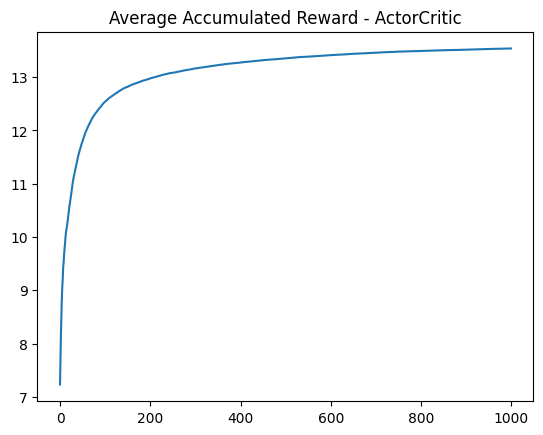

In [95]:
ActCrit_policies, ActCrit_reward2 = Avg_AccReward(ActorCritic)

In [96]:
pd.DataFrame(ActCrit_policies)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,a2,a2,a2,a2,a2,a2,a2,a2,a1,a2,a2,a3,a1,a2,a2,a2
1,a2,a3,a2,a2,a2,a2,a2,a2,a4,a2,a4,a2,a4,a2,a2,a2
2,a3,a2,a2,a2,a2,a2,a2,a2,a4,a2,a3,a2,a4,a2,a1,a2
3,a3,a2,a2,a2,a2,a2,a2,a2,a4,a2,a2,a2,a4,a2,a2,a2
4,a3,a2,a2,a2,a2,a2,a2,a2,a3,a2,a2,a2,a4,a2,a1,a2
5,a2,a2,a2,a2,a2,a2,a2,a2,a3,a3,a2,a2,a1,a2,a2,a2
6,a2,a2,a2,a2,a2,a2,a2,a2,a2,a2,a1,a2,a1,a2,a2,a2
7,a2,a2,a2,a2,a2,a2,a2,a2,a1,a4,a3,a2,a4,a2,a2,a2
8,a3,a2,a2,a2,a2,a2,a2,a2,a4,a2,a2,a2,a1,a2,a2,a2
9,a3,a3,a2,a2,a2,a2,a2,a2,a3,a2,a3,a2,a1,a2,a2,a2


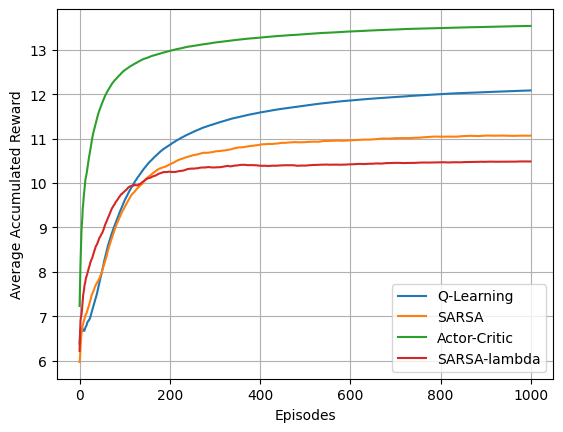

In [100]:
plt.plot(QLearn_reward2, label='Q-Learning')
plt.plot(SARSA_reward2, label='SARSA')
plt.plot(ActCrit_reward2, label='Actor-Critic')
plt.plot(SARSA_lambda_reward, label='SARSA-lambda')

plt.xlabel('Episodes')
plt.ylabel('Average Accumulated Reward')
plt.legend()
plt.grid()
plt.show()